In [1]:
import sys
sys.path.append("../../src")

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from gaussian_systems.initial_state import GaussianCVState
from gaussian_systems.systems import GaussianCVSystem, single_pole_ou_embedding

In [3]:
n = 2 #system size

#state parameters
ra, rb = ( (1.0,0.0), (1.0,0.0))
da, db = ( (1/np.sqrt(2))*(3+3j), (1/np.sqrt(2))*(-3-3j))

#environment parameters
kappa = 1
delta_E, delta_2 = 10*kappa, 0.1*kappa
frequency_array = np.array([0,delta_2])
gamma = 0.5*kappa
n_bar = 0

In [4]:
#use GaussianCVState constructor to generate the mean and covariance matrix
my_state = GaussianCVState.vacuum(n)
my_state.single_mode_squeeze(ra,1).single_mode_squeeze(rb,2)
my_state.single_mode_displacement(da,1).single_mode_displacement(db,2)

In [5]:
#use GaussianCVSystem constructor to generate the hamiltonian and linbladian matrix
my_system = GaussianCVSystem.free_evolution(n,frequency_array)

In [6]:
#use single_poled_ou_embedding to embed your n-mode state+system into an n+1 mode state+system
#where the n+1-th mode corresponds to an OU memory kernel with a single central frequency 
embedded_state, embedded_system = single_pole_ou_embedding(
    state=my_state, 
    system=my_system,
    subsystem=(1,2),
    coupling_types=("annihilation","annihilation"),
    memory_rate=gamma,
    env_freq=delta_E,
    decay_rate=kappa, 
    thermal_occupation=n_bar
)

In [7]:
embedded_system.hamiltonian_matrix

array([[ 0. ,  0. ,  0.5,  0. ,  0. ,  0. ],
       [ 0. ,  0.1,  0.5,  0. ,  0. ,  0. ],
       [ 0.5,  0.5, 10. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0.5],
       [ 0. ,  0. ,  0. ,  0. ,  0.1,  0.5],
       [ 0. ,  0. ,  0. ,  0.5,  0.5, 10. ]])

In [6]:
t_span = (0,20/delta_2)
t_eval = np.linspace(t_span[0],t_span[1],1000)
a_tol, r_tol = 1e-9, 1e-7
method = "Radau"
mysols_varied_nbar = []
for i in range(len(n_bars)):
    dxdt = dxdt_varied_nbar[i]
    x0 = x0_varied_nbar[i]
    mysols = solve_ivp(fun=dxdt,y0=x0,t_span=t_span,t_eval=t_eval,method=method,a_tol=a_tol,r_tol=r_tol)
    mysols_varied_nbar.append(mysols)

C:\Programs\Anaconda3\envs\gaussian-env\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `a_tol`, `r_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


In [8]:
np.eye(4, 3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [7]:
ts = mysols_varied_nbar[0].t

In [14]:
ents_varied_nbar = []
for mysols in mysols_varied_nbar:
    ents = [compute_logarithmic_negativity(covariance_subsystem(extract_mean_covariance(yt)[1],(1,2))) for yt in mysols.y.T]
    ents_varied_nbar.append(ents)

In [9]:
import matplotlib.pyplot as plt

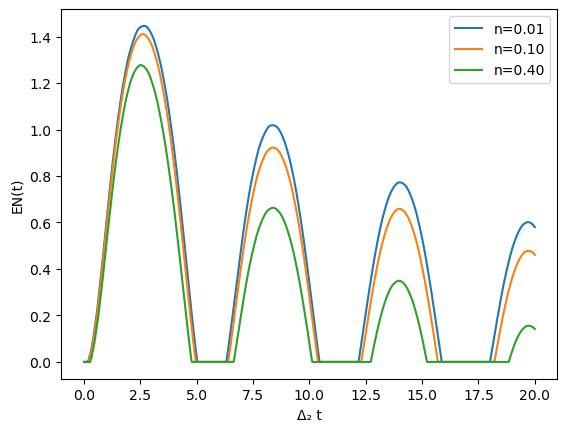

In [10]:
plt.plot(ts*delta_2, ents_varied_nbar[0],ts*delta_2, ents_varied_nbar[1],ts*delta_2, ents_varied_nbar[2])
plt.xlabel("\u0394\u2082 t")
plt.ylabel("EN(t)")
plt.legend(["n=0.01","n=0.10","n=0.40"])

In [11]:
from gaussian_systems.metrics import valid_covariance

In [15]:
validity_time_trace = []
for mysols in mysols_varied_nbar:
    valids = [valid_covariance(extract_mean_covariance(yt)[1]) for yt in mysols.y.T]
    validity_time_trace.append(valids)

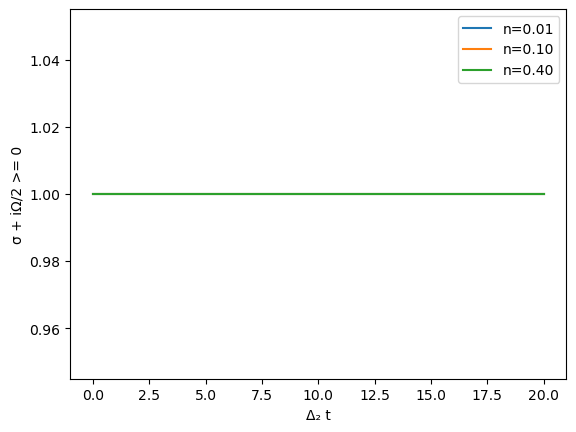

In [17]:
plt.plot(ts*delta_2, validity_time_trace[0],ts*delta_2, validity_time_trace[1],ts*delta_2, validity_time_trace[2])
plt.xlabel("\u0394\u2082 t")
plt.ylabel("\u03C3 + i\u03A9/2 >= 0")
plt.legend(["n=0.01","n=0.10","n=0.40"])